In [31]:
import numpy as np
from veripulse.pulse import run_grape_si, run_grape, run_crab, PulseConfig, PulseResult
from veripulse.gates import rx, rhox, pack_subspace_states, extract_subspace_states, Qobj, operator_to_vector, vector_to_operator
%matplotlib inline

from pathlib import Path

In [32]:
# root path
path_data = Path.cwd().parent/"data"
path_data

PosixPath('/users/home/gustiani/VeriPulse/data')

## Default pulse configuration is based on the paper below 

***from  Frank et al., npj Quantum Information 3, 48 (2017)***
<ul>
    <li>Hilbert space:    2-level (|0⟩, |−1⟩ subspace)</li>
    <li>Hamiltonian:      H = 2π·Δ·Sz + 2π·Ω·[X(t)·Sx + Y(t)·Sy]</li>
    <li>Ω_max:            10 MHz</li>
    <li>T:                75 ns  (π-pulse)</li>
<li>n_tslots:         100</li>
<li>Detuning range:   Δ ∈ [-10Ω, +10Ω] for robustness scan</li>
<li>Decoherence:      optional pure dephasing, T2* ~ 1–3 µs (negligible for single 75 ns pulse)</li>
<li>Target (π):       |0⟩ → |−1⟩</li>
<li>Target (π/2):     U = (I − i·σx)/√2</li>
 <li>AWG timing resolution: ~15ps. The AWG can update the pulse amplitude every 1/65×10⁹ s ≈ 15.4 ps</li>   
<li>AWG amplitude resolution8 bit: The amplitude X(t) ∈ [-1, 1] is discretized into 2⁸ = 256 levels</li>
</ul>


In [33]:
# default pulse setting is based on the npj paper
conf1 = PulseConfig(max_wall_time = 50000, max_iter =10000, fid_err_targ=1e-10) 
conf1.print()

Parameter                    Value  Description                   
───────────────────────────────────────────────────────────────────────────
omega_drift              1.000e+07  (Hz) Drift/Rabi frequency
T2_star                  2.000e-06  (s) T2-star
drive_error              0.000e+00  [0,1] Misalignment of control on the x- and y-axis
detuning                 0.000e+00  (coefficient) Detuning with respect to omega
evo_time                 7.500e-08  (s) Total evolution time
num_tslots                     100  (int) Number of pulses
amp_lbound              -1.000e+00  (coefficient) Lower bound of pulse amplitude
amp_ubound               1.000e+00  (coefficient) Upper bound of pulse amplitude
awg_resolution           1.500e-11  (ps) AWG resolution
fid_err_targ             1.000e-10  (float) Convergence criteria
max_iter                     10000  (int) Cap of iterations
max_wall_time                50000  (s) Cap of compute time
init_pulse_type                RND  (str) First pulse gu

In [4]:
angles= [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4]

In [10]:
# initial states with a little noise 
err = 0
rho_init = Qobj([[1-err, 0], [0, err]])
# target states 
rho_targets = [Qobj(rhox(a)) for a in angles]

# Single optimisations

In [11]:
# single optimisations 
res_indiv = []
for rho_targ in rho_targets:
    res = run_grape(operator_to_vector(rho_init), operator_to_vector(rho_targ), config=conf1)
#    res = run_crab(operator_to_vector(rho_init), operator_to_vector(rho_targ), config=conf1)
    res_indiv.append(res)

In [12]:
pulse_res = PulseResult(
    config=conf1,
    mode="GRAPE",
    results=res_indiv,
    rho_targets=rho_targets,
    final_amps=np.stack([r.final_amps for r in res_indiv]),
    label="experiment invid",
    state_labels=angles
)

In [8]:
#pulse_res.save(path_data/"test_crab.json")

In [13]:
pulse_res.display()


════════════════════════════════════════════════════════════
  experiment invid  [GRAPE]
  detuning=0.000e+00  drive_error=0.000e+00
  states: 0, 0.7853981633974483, 1.5707963267948966, 2.356194490192345, 3.141592653589793, 3.9269908169872414, 4.71238898038469, 5.497787143782138
════════════════════════════════════════════════════════════
         err_HS   err_Uhlmann   fid_compute               termination
──────────────────────────────────────────────────────────────────────
      5.249e-09     7.246e-05        5               function converged
      9.173e-07     9.582e-04        7               function converged
      4.224e-06     2.057e-03       16               function converged
      8.495e-06     2.919e-03       42               function converged
      5.838e-06     2.419e-03       56               function converged
      7.465e-06     2.736e-03       30               function converged
      5.163e-06     2.275e-03       11               function converged
      1.729e-

In [10]:
#pulse_res.plot_pulse()
res2 = PulseResult.load(path_data/"test_grape.json")

In [11]:
res2.display()


════════════════════════════════════════════════════════════
  experiment 1  [GRAPE]
  detuning=0.000e+00  drive_error=0.000e+00
  states: 0, 3.141592653589793, 0.7853981633974483, 3.9269908169872414, 1.5707963267948966, 4.71238898038469, 2.356194490192345, 5.497787143782138
════════════════════════════════════════════════════════════
         err_HS        err_Uhlmann   fid_compute               termination
───────────────────────────────────────────────────────────────────────────
      3.274e-09          5.722e-05        5               function converged
      5.208e-06          2.285e-03       54               function converged
      4.064e-07          6.377e-04        8               function converged
      1.005e-05          3.174e-03       26               function converged
      1.283e-06          1.133e-03       41               function converged
      5.202e-06          2.283e-03       13               function converged
      7.758e-06          2.789e-03       40      

# GRAPE-AVG 

In [14]:
# test noise averaging methode 
vRho_init, vRho_target, U_big = pack_subspace_states(
    rotations = [rx(t) for t in angles],
    rho_init = rho_init,
)

In [28]:
res8 = run_grape_si(vRho_init, vRho_target, U_big, lam=0.1, config=conf1)

Secret Independence =  0.49319753772498254
fidelity error =  0.11658185614456329
Secret Independence =  0.4931866967430667
fidelity error =  0.11657227672223694
Secret Independence =  0.4931758317309648
fidelity error =  0.11656268532129208
Secret Independence =  0.49313225021998575
fidelity error =  0.11652431913811288
Secret Independence =  0.4929559813056344
fidelity error =  0.1163708457216433
Secret Independence =  0.49280181382109134
fidelity error =  0.1162387712017935
Secret Independence =  0.4927901145214679
fidelity error =  0.11622876723005764
Secret Independence =  0.4927572424283743
fidelity error =  0.11620071881416436
Secret Independence =  0.4927454439933592
fidelity error =  0.11619066722282398
Secret Independence =  0.49269811634533106
fidelity error =  0.11615046042991631
Secret Independence =  0.49250666388484365
fidelity error =  0.11598962707717413
Secret Independence =  0.49178661957573055
fidelity error =  0.11540863982349683
Secret Independence =  0.49177262525

In [34]:
pr_grape_avg = PulseResult(
    config=conf1,
    mode="GRAPE_AVG",
    result=res8,
    rho_targets=rho_targets,
    final_amps=res8.final_amps,
    label="experiment avg",
    state_labels=angles
)
pr_grape_avg.display()


════════════════════════════════════════════════════════════
  experiment avg  [GRAPE_AVG]
  detuning=0.000e+00  drive_error=0.000e+00
  states: 0, 0.7853981633974483, 1.5707963267948966, 2.356194490192345, 3.141592653589793, 3.9269908169872414, 4.71238898038469, 5.497787143782138
════════════════════════════════════════════════════════════
[global]         err_HS   fid_compute               termination
─────────────────────────────────────────────────────────────────
              6.482e-07       276              function converged

[per state]    state_label              err_HS   err_Uhlmann
────────────────────────────────────────────────────────────
               0                     9.187e-08     8.526e-05
               0.7853981633974483    1.038e-05     1.137e-03
               1.5707963267948966    4.048e-05     2.251e-03
               2.356194490192345     6.744e-05     2.907e-03
               3.141592653589793     3.757e-05     2.168e-03
               3.926990816987241

In [35]:
res8 = run_grape_si(vRho_init, vRho_target, U_big, lam=0.05, config=conf1)

pr_grape_avg = PulseResult(
    config=conf1,
    mode="GRAPE_AVG",
    result=res8,
    rho_targets=rho_targets,
    final_amps=res8.final_amps,
    label="experiment avg",
    state_labels=angles
)
pr_grape_avg.display()

Secret Independence =  0.4681959732883501
fidelity error =  0.12919726994156927
Secret Independence =  0.4681280581629706
fidelity error =  0.12919752327851636
Secret Independence =  0.4680599964282791
fidelity error =  0.12919777397822463
Secret Independence =  0.4677870157723175
fidelity error =  0.12919877327335857
Secret Independence =  0.4673590497709709
fidelity error =  0.12920032016630953
Secret Independence =  0.46728943189709393
fidelity error =  0.12920054192791508
Secret Independence =  0.46701021329569853
fidelity error =  0.12920142552914837
Secret Independence =  0.4658814129234129
fidelity error =  0.12920490475757732
Secret Independence =  0.46401501298426606
fidelity error =  0.12921034619941923
Secret Independence =  0.46393842869458923
fidelity error =  0.12921045934882186
Secret Independence =  0.463861715232763
fidelity error =  0.12921057257469212
Secret Independence =  0.46355405039383646
fidelity error =  0.12921102253761801
Secret Independence =  0.46257240422

In [37]:
conf1.print()

Parameter                    Value  Description                   
───────────────────────────────────────────────────────────────────────────
omega_drift              1.000e+07  (Hz) Drift/Rabi frequency
T2_star                  2.000e-06  (s) T2-star
drive_error              0.000e+00  [0,1] Misalignment of control on the x- and y-axis
detuning                 0.000e+00  (coefficient) Detuning with respect to omega
evo_time                 7.500e-08  (s) Total evolution time
num_tslots                     100  (int) Number of pulses
amp_lbound              -1.000e+00  (coefficient) Lower bound of pulse amplitude
amp_ubound               1.000e+00  (coefficient) Upper bound of pulse amplitude
awg_resolution           1.500e-11  (ps) AWG resolution
fid_err_targ             1.000e-10  (float) Convergence criteria
max_iter                     10000  (int) Cap of iterations
max_wall_time                50000  (s) Cap of compute time
init_pulse_type                RND  (str) First pulse gu

In [17]:
res = PulseResult.load(path_data/"test_avg.json")

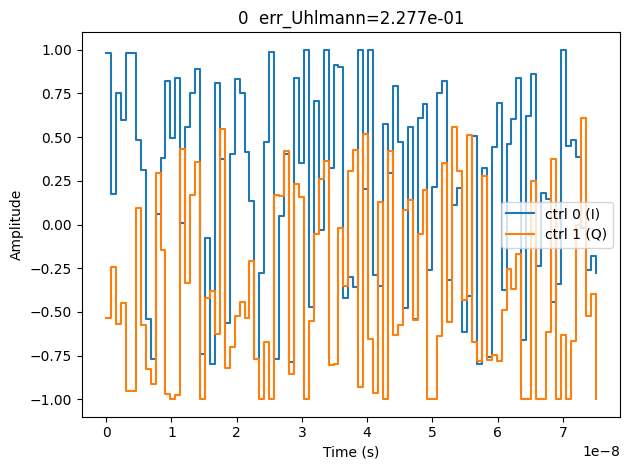

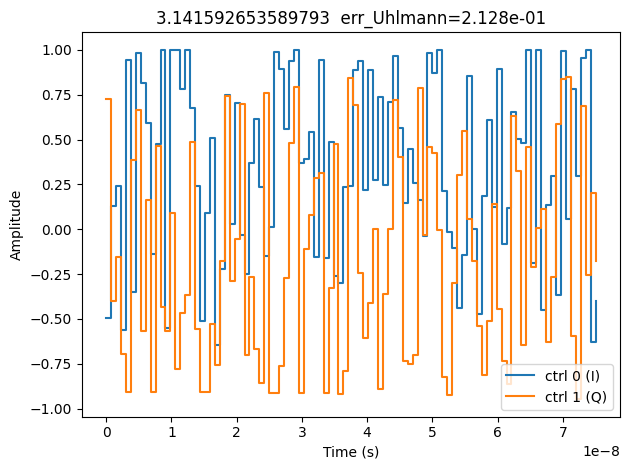

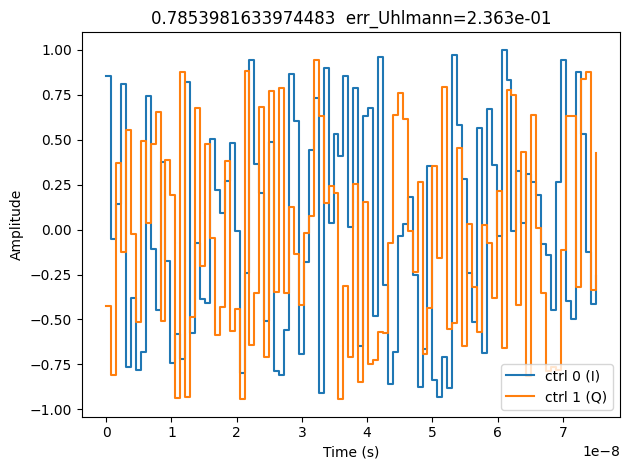

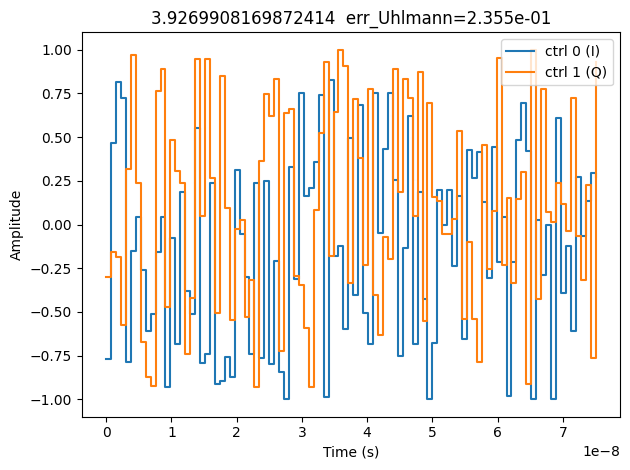

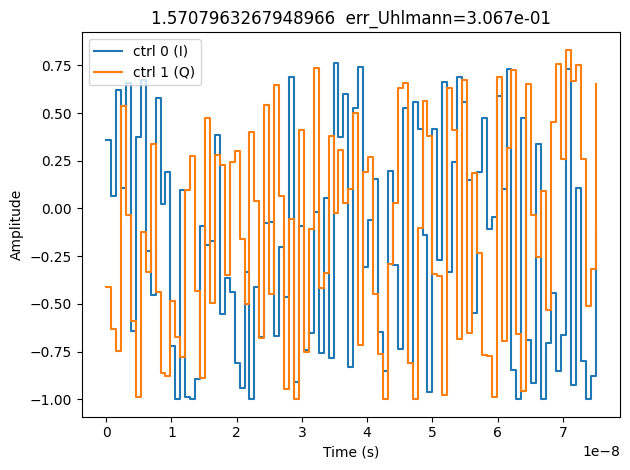

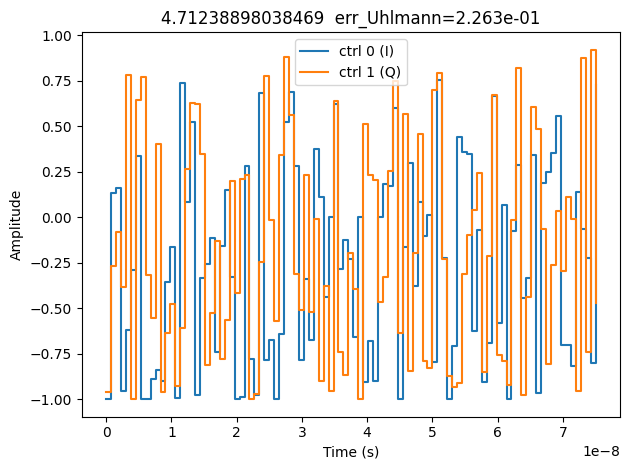

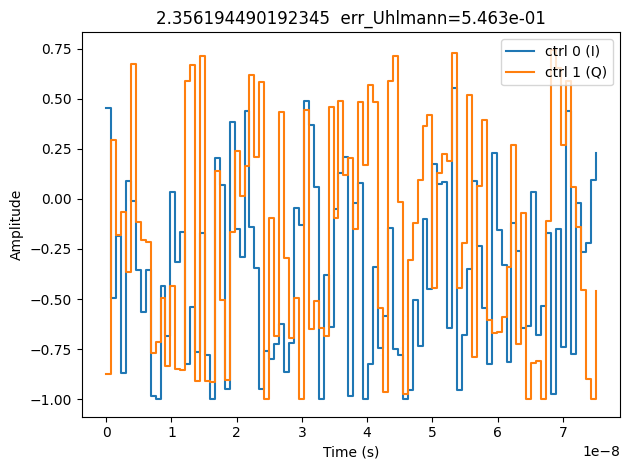

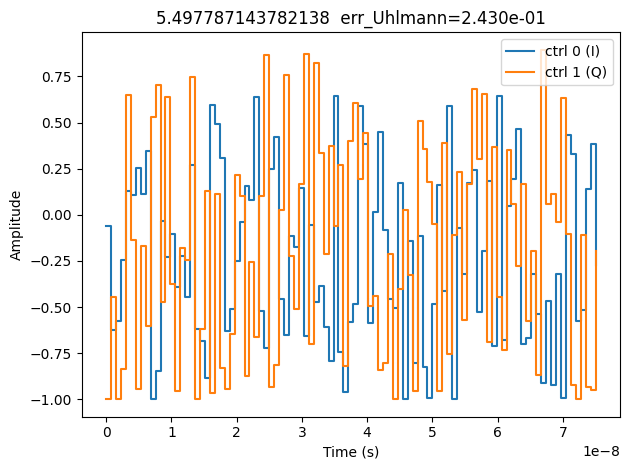

In [18]:
res.plot_pulse()